Load Final Dataset & Preprocessor
 Imports

In [23]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV


Load Dataset

In [24]:
import pandas as pd

df = pd.read_csv("dataset.csv")

X = df.drop(columns=["target_runs_next_match"])
y = df["target_runs_next_match"]

df.head()



,runs_scored,balls_faced,wickets_taken,avg_runs_last_5,avg_runs_last_10,venue_avg_runs,pvt_avg_runs,career_avg_runs,batting_team,bowling_team,venue,target_runs_next_match
0,0.000000,2,1,0.0,0.0,0.416667,0.000000,1.050000,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,0.500000
1,26.333333,77,0,0.0,0.0,5.809524,6.322222,4.439815,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,0.833333
2,1.000000,10,1,0.0,0.0,3.404762,2.638889,3.560606,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,5.166667
3,2.000000,12,1,0.0,0.0,4.750000,4.270833,3.669444,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,6.333333
4,1.333333,7,1,0.0,0.0,4.041667,4.533333,4.285461,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,4.166667


Load Preprocessing Pipeline

In [25]:
preprocessor = joblib.load("feature_pipeline.pkl")

X_processed = preprocessor.transform(X)


Train–Test Split (Time-Series Safe)

In [26]:
split_idx = int(X_processed.shape[0] * 0.8)

X_train = X_processed[:split_idx]
X_test = X_processed[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


Baseline Model (Rolling Average)
🔹 Why baseline?

To ensure ML models beat a simple approach

🔹 Baseline Prediction

In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_pred = X.iloc[:split_idx]["avg_runs_last_10"].values
baseline_true = y.iloc[:split_idx]

baseline_rmse = np.sqrt(
    mean_squared_error(baseline_true, baseline_pred)
)

baseline_rmse



np.float64(3.650587909695222)

Random Forest Model
🔹 Train Model

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

Evaluate

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

rf_rmse, rf_mae, rf_r2



(np.float64(3.554927705935318), 2.613945329757021, 0.1193517354149568)

6️⃣ XGBoost Model (Main Model)
🔹 Install & Import

In [37]:
!pip install xgboost
from xgboost import XGBRegressor


Train XGBoost

In [36]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluate

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

xgb_pred = xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

xgb_rmse, xgb_mae, xgb_r2



(np.float64(3.5567842926777136), 2.6209572394764153, 0.11843164534658224)

Hyperparameter Tuning (GridSearchCV)

In [40]:
param_grid = {
    "max_depth": [4, 6],
    "learning_rate": [0.03, 0.05],
    "n_estimators": [200, 300]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1
)

grid.fit(X_train, y_train)

grid.best_params_


Fitting 3 folds for each of 8 candidates, totalling 24 fits


{'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200}

Save Best Model

In [41]:
best_xgb = grid.best_estimator_

joblib.dump(best_xgb, "xgb_model.joblib")
print("✅ xgb_model.joblib saved")


✅ xgb_model.joblib saved


Feature Importance with SHAP
🔹 Install & Import

In [42]:
!pip install shap
import shap


SHAP Analysis

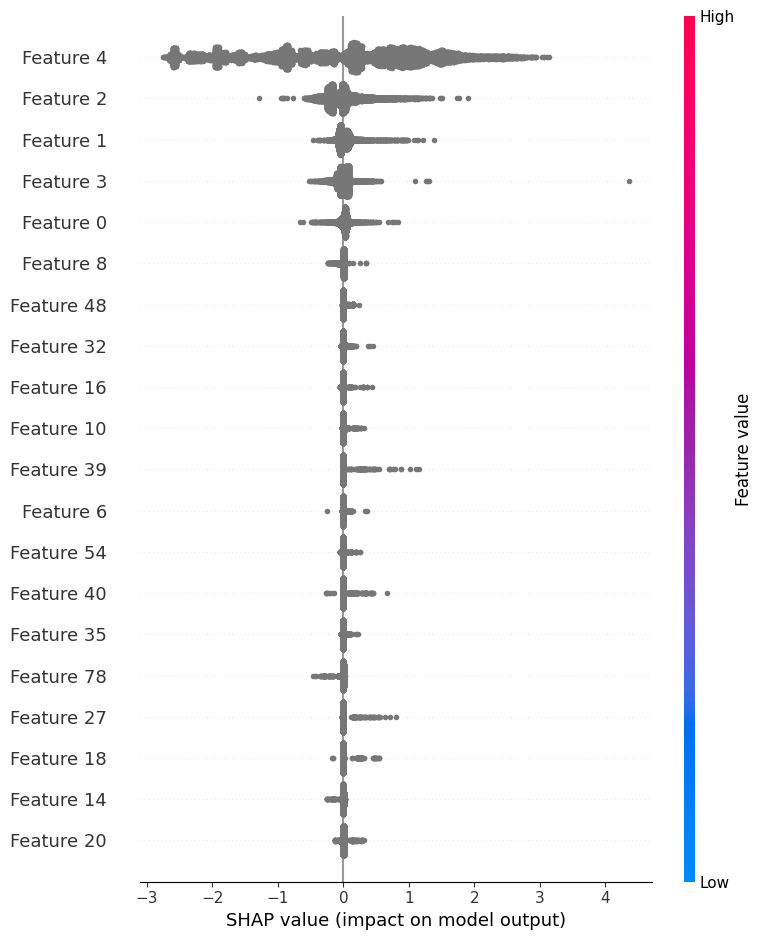

In [43]:
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train)


Final Model Comparison Table

In [44]:
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost"],
    "RMSE": [baseline_rmse, rf_rmse, xgb_rmse],
    "MAE": [None, rf_mae, xgb_mae],
    "R2": [None, rf_r2, xgb_r2]
})

results


,Model,RMSE,MAE,R2
0,Baseline,3.650588,NaN,NaN
1,Random Forest,3.554928,2.613945,0.119352
2,XGBoost,3.556784,2.620957,0.118432
